# Trabajo final: Optimización del Presupuesto Operativo - DADEP (Minimizacion) 



## Formulación enunciado
---
El Departamento Administrativo de la Defensoría del Espacio Público (DADEP) busca optimizar su presupuesto destinado a los **Servicios de Soporte Operativo** para el próximo año. El objetivo es **minimizar el gasto total** en tres rubros principales (Seguridad, Limpieza y Mantenimiento), garantizando que se cumplan los topes mínimos operativos (80% del presupuesto actual) y respetando las políticas internas de seguridad de la entidad.
>"https://www.datos.gov.co/Vivienda-Ciudad-y-Territorio/Presupuesto-DADEP/8rih-qmrc/about_data"



### Conjuntos y Parámetros
>#### **Conjuntos**
>* $I$: Conjunto de servicios de soporte operativo. 
>>$I = \{\text{Seguridad, Limpieza, Mantenimiento}\}$

>#### **Parámetros**
>* $b_i:$ presupuesto mínimo requerido para que el rubro $i \in I$ pueda operar.
>* $p:$ presupuesto global máximo autorizado para todos los servicios de soporte.
>* $q:$ mínimo porcentaje de inversión obligatoria en el rubro de Seguridad.

### Variables de Decisión
> $x_i:$ dinero a ser asignado (en COP) al rubro $i\in I$


### Restricciones
> 1. Cada rubro $i\in I$ tiene un requerimiento mínimo de presupuesto estipulado $b_i$
>> $x_i \geq b_i, \; \forall i\in I$

> 2. El presupuesto global asignado no puede superar el tope máximo $p$
>> $\sum_{i\in I} x_i \leq p$

> 3. La asignación presupuestal para Seguridad debe ser por lo menos $q$ (ej. 0.5) del total del presupuesto asignado.
>> $q*\sum_{i\in I}x_i \leq x_{\text{s}}$

> **Naturaleza de Variables**
>>$x_i\geq 0 , \; \forall i\in I$

### Función Objetivo
> Minimizar el presupuesto total asignado a los servicios de soporte o rubros.
>> $\min{ \sum_{i\in I} x_i}$

## Importación de librerías
---
En esta práctica usaremos:
* El paquete `pandas` es muy útil para el análisis de datos en general. Le asignamos el alias de `pd`.
* El paquete `pulp` permite crear modelos de optimización, crear variables, añadir restricciones y muchos más. Le asignamos el alias de `lp`.

In [3]:
import pandas as pd
import pulp as lp

## Creación de Parámetros
---
### Lectura del archivo de soporte
Los datos que necesitamos para esta práctica se encuentran disponibles en el archivo `Presupuesto_DADEP.xlsx`.
Para este caso el conjunto son los rubros salariales a los que se le definira el presupuesto. Se realiza una lista que guarde cada rubro.

In [6]:
datos = pd.read_excel('Presupuesto_DADEP.xlsx', sheet_name='Data')

### Procesamiento de archivos de soporte

En esta fase se definen y estructuran los **Conjuntos** y **Parámetros** fundamentales del modelo matemático. La información extraída del archivo de Excel se procesa mediante Pandas y se transforma en listas y diccionarios nativos de Python. Este paso es crucial para facilitar la integración de las variables presupuestales (como los rubros de Seguridad, Limpieza y Mantenimiento, junto con sus valores) en la sintaxis de la librería de optimización PuLP.

In [9]:
# Escribe los 3 nombres exactos con los que se van a trabajar de la fila en la hoja de excel
rubros_buscados = [
    'Servicios de protección (guardas de seguridad)',
    'Servicios de limpieza general',
    'Servicios de mantenimiento y reparación de computadores y equipos periféricos'
]

#filtra la tabla original para solo tener esos 3 datos
df_filtrado = datos[datos['RUBRO'].isin(rubros_buscados)]


### Conjuntos
$I$: Conjunto de rubros de servicios operativos

In [10]:
#Crea lista I con las 3 áreas a analizar de la columna Rubro
I = df_filtrado['RUBRO'].to_list()

### Parámetros

* $b_i:$ Presupuesto mínimo requerido para asegurar la operatividad del rubro $i\in I$
* $p:$ Presupuesto global máximo autorizado para los servicios de soporte
* $q:$ Proporción mínima de inversión obligatoria destinada al rubro de Seguridad


In [11]:
#Recorre tabla filtrada fila de rubro y valor y multiplica por 0.8 para obtener el presupuesto mínimo requerido para que el rubro opere 
b = {row["RUBRO"]: row["VALOR"] * 0.8 for _, row in df_filtrado.iterrows()}
#El presupuesto global asignado no puede superar el tope máximo, sumando el valor de los 3 rubros en la tabla filtrada columna valor
p = df_filtrado['VALOR'].sum()
#mínimo porcentaje de inversión obligatoria en el rubro de Seguridad, corresponde al 55%
q = 0.55


## Modelamiento
---

### Declaración del modelo
El primer paso para desarrollar un problema de optimización en `pulp` es declarar el objeto `lp.LpProblem` en el cual podemos agregar variables, restricciones y la función objetivo. Como convención para todos los trabajos y entregas de este curso, este objeto se llamará `problema`. Este objeto nos permite añadir los componentes del problema de optimización.

El método `lp.LpProblem()` crea un problema lineal de optimización.

* Crea un objeto modelo en PuLP (`lp.LpProblem`) llamado `problema`
* Indica el sentido de la optimización: maximizar o minimizar


> **Recuerda** que el sentido se indica con el argumento `sense` en `lp.LpProblem()`, que toma valores `lp.LpMaximize` o `lp.LpMinimize`

In [ ]:
# your code here
problema = lp.LpProblem(name="Optimizacion_Presupuesto", sense=lp.LpMinimize)


In [ ]:
# Esta celda esta reservada para uso del equipo docente


## Variables de decisión
* $x_i:$ Dinero asignado (en COP) al rubro $i\in I$

* Crea las variables del modelo: `x`, usando el método `lp.LpVariable.dicts()`.
* Especifica el nombre de las variables como `inversion` con el argumento `name`.
* Especifica el conjunto sobre el cual está indexado la variable con el argumento `indexs` o `indices`. 
* Especifica el límite inferior en 0 con el argumento `lowBound`.
* Especifica el tipo de variable con el argumento `cat` (continua: `lp.LpContinuous`, entera: `lp.LpInteger` o binaria: `lp.LpBinary`).


> **Para crear un grupo de variables** usa el método `lp.LpVariable.dicts(name, indexs, lowBound, upBound, cat)`

Por ejemplo:
```python
x = lp.LpVariable.dicts(name='inversion', indexs=I, lowBound=0, upBound=None, cat=lp.LpContinuous)
 
```

> Donde:
> - `name`: el nombre de la variable
> - `indexs`: lista de las llaves que tendrá el diccionario de variables. Normalmente corresponde a los conjuntos
> - `lowBound`: el límite inferior de la variable. Por defecto es `None`, esto es, el infinito negativo
> - `upBound` : el límite superior de la variable. Por defecto es `None`, esto es, el infinito positivo
> - `cat`: el tipo de variable: continua: `lp.LpContinuous`, entera: `lp.LpInteger` o binaria: `lp.LpBinary`


In [15]:
# your code here
x = lp.LpVariable.dicts(name='Dinero', indices=I, lowBound=0, upBound=None, cat=lp.LpContinuous)

In [ ]:
# Esta celda esta reservada para uso del equipo docente


In [ ]:
# Esta celda esta reservada para uso del equipo docente

### Función Objetivo
> Minimizar el gasto total asignado a los servicios de soporte operativo.
>> $\min{ \sum_{i\in I} x_i}$


* Crea la función objetivo y agregala al modelo `problema`. A continuación, te explicamos como se usan las sumatorias en `pulp`

> **Recuerda** que para agregar una función objetivo o restricción a un modelo en pulp se usa la sintaxis: `<modelo> += <expresion>`

> **Recuerda** que una función objetivo en `pulp` consiste en multiplicar variables de tipo `lp.pulp.Variable` (como `x`) por constantes así: `<int|float> * <variable>` y luego sumarlas o restarlas así: `<const1> * <var1> + <const2> * <var2>`

> **Recuerda** que, para evitar escribir una sumatoria de muchos términos uno a uno, `pulp` permite crear sumatorias que recorran conjuntos siempre y cuando las variables esten indexadas (como `x`). Para esto, utiliza `lp.lpSum(<expresion> for <indices> in <conjunto>)`.

> **Ejemplo**:
>> $ \sum_{i \in I}c_i x_i$
es equivalente a `lp.lpSum(c[i]*x[i] for i in I)`

In [16]:
# your code here
problema += lp.lpSum(x[i] for i in I), "Función Objetivo"

In [ ]:
# Esta celda esta reservada para uso del equipo docente

In [ ]:
# Esta celda esta reservada para uso del equipo docente

### Restricciones

> **Recuerda** que para crear restricciones se debe usar la sintaxis: `<modelo> += <expresion_lado_izq> ==|>=|<= <expresion_lado_der>, 'Nombre_de_la_restriccion'`

> **Recuerda** que las expresiones son combinaciones lineales de las variables, como: `<var1>*<const1> + <var2>*<const2>`

> **Recuerda** que puedes usar `lp.lpSum()` para crear sumatorias

> **Recuerda** que para crear múltiples restricciones usando $\forall i \in I$, se debe utilizar la sintaxis:
>>    * `for i in I:` 
>>       * `<restriccion>`

```
> **Advertencia**: `pulp` no permite sobreescribir restricciones, entonces, si ya creaste una restricción y quieres crearla de nuevo para corregir algo, asegúrate de volver a crear el modelo `problema` desde el principio (nosotros haremos esto antes de calificar, no te preocupes).

**Pregunta 4 (15 puntos)**

* Crea la siguiente restricción, asignale el nombre `'R1_'+str(<indice_del_para_todo>)` y añadela al modelo:
>Realiza un ciclo para los elementos de la lista I, donde el dinero asignado a cada elemento de la lista I (el cual es la variable de decision) debe ser mayor o igual a bi ósea el presupuesto mínimo requerido para que el rubro pueda operar

> 1. Cada rubro $i\in I$ tiene un requerimiento mínimo de presupuesto estipulado $b_i$
>> $x_i \geq b_i, \; \forall i\in I$

In [18]:
# your code here
#Mínimo requerido por rubro
for i in I:
    problema += x[i] >= b[i], 'R1_' + str(i)

In [ ]:
# Esta celda esta reservada para uso del equipo docente


**Pregunta 5 (15 puntos)**

* Crea la siguiente restricción, asignale el nombre `'R2'` y añadela al modelo:
>Sumatoria de la variable de decisión del dinero asignado a cada elemento de la lista I, siendo menor o igual para que no pase el presupuesto total asignado para los servicios de soporte en la columna valor (p) y se le asigna r2

> 2. El presupuesto global asignado no puede superar el tope máximo $p$
>> $\sum_{i\in I} x_i \leq p$

In [19]:
# your code here
problema += lp.lpSum(x[i] for i in I) <= p, 'R2'


In [ ]:
# Esta celda esta reservada para uso del equipo docente


**Pregunta 6 (15 puntos)**

* Crea la siguiente restricción, asignale el nombre `'R3'` y añadela al modelo:
>(el porcentaje de 0,55 o 55% obligatorio para el rubro de seguridad) multiplica a la sumatoria de la variable de decisión del dinero asignado a cada elemento de la lista I 

>-Significa que saca el 55% del dinero que se va a repartir

>-Sera menor o igual a la variable de seguridad y así sea al menos el 55% del presupuesto total que se asigne

> 3. La asignación presupuestal para Seguridad debe ser por lo menos $q$ (ej. 0.5) del total del presupuesto asignado.

>> $q*\sum_{i\in I}x_i \leq x_{\text{s}}$


In [20]:
# your code here
problema += q * lp.lpSum(x[i] for i in I) <= x['Servicios de protección (guardas de seguridad)'], 'R3'

In [ ]:
# Esta celda esta reservada para uso del equipo docente

### Invocar el optimizador

Ahora que el modelo está listo, viene la mejor parte: ¡Correr el modelo! La celda a continuación se encarga de llamar al optimizador de `pulp` y guardar las soluciones del modelo (si llega a optimalidad). Más adelante extraeremos la solución y otras métricas de interés del objeto `problema` y del diccionario de variables `x`.

> **Recuerda** debes utilizar la instrucción `<modelo>.solve()` para invocar al optimizador y resolver el problema. 


In [21]:
# your code here
problema.solve()

1

## Reporte de resultados
---

**Estado del optimizador, función objetivo y otros indicadores**

A continuación puede evaluar la función objetivo óptima además de el estado del optimizador. (Minimizacion)
> **Recuerda** que al finalizar de correr el modelo, `<modelo>.status` tomará un valor de 1, -1, -2 o -3, que hace referencia a algún estado del optmizador:
*  0 $\rightarrow$ Sin Resolver: No se ha usado `<modelo>.solve()`
*  1 $\rightarrow$ Óptimo
* -1 $\rightarrow$ Infactible
* -2 $\rightarrow$ No acotado 
* -3 $\rightarrow$ Otros

> **Recuerda** que `lp.LpStatus` es un diccionario en PuLP que tiene como llaves los `status` del optimizador (número) en `<modelo>.status`, y para cada `status` contiene el estado del optimizador en palabras.

> **Recuerda** que puedes inspeccionar el contenido de `lp.LpStatus`, simplemente corriendolo en una celda

> **Recuerda** que `<modelo>.objective` contiene la **expresión** de la función objetivo, sin embargo, para conocer el valor de la función objetivo se debe reemplazar los valores de las variables en la solución dentro de esta expresión. Por fortuna, PuLP tiene una función que hace justo eso: `lp.value(<expresion>)`.

In [26]:
# your code here
print("Estado:", lp.LpStatus[problema.status])
print("Valor minimizado del gasto total:", lp.value(problema.objective))
for i in I:
    valor_original = df_filtrado[df_filtrado['RUBRO'] == i]['VALOR'].iloc[0]
    print(f"{i} -> Original: {valor_original} | Nueva asignacion: {x[i].varValue}")



Estado: Optimal
Valor minimizado del gasto total: 644444440.0
Servicios de protección (guardas de seguridad) -> Original: 361600000.0 | Nueva asignacion: 354444440.0
Servicios de limpieza general -> Original: 275000000.0 | Nueva asignacion: 220000000.0
Servicios de mantenimiento y reparación de computadores y equipos periféricos -> Original: 87500000.0 | Nueva asignacion: 70000000.0


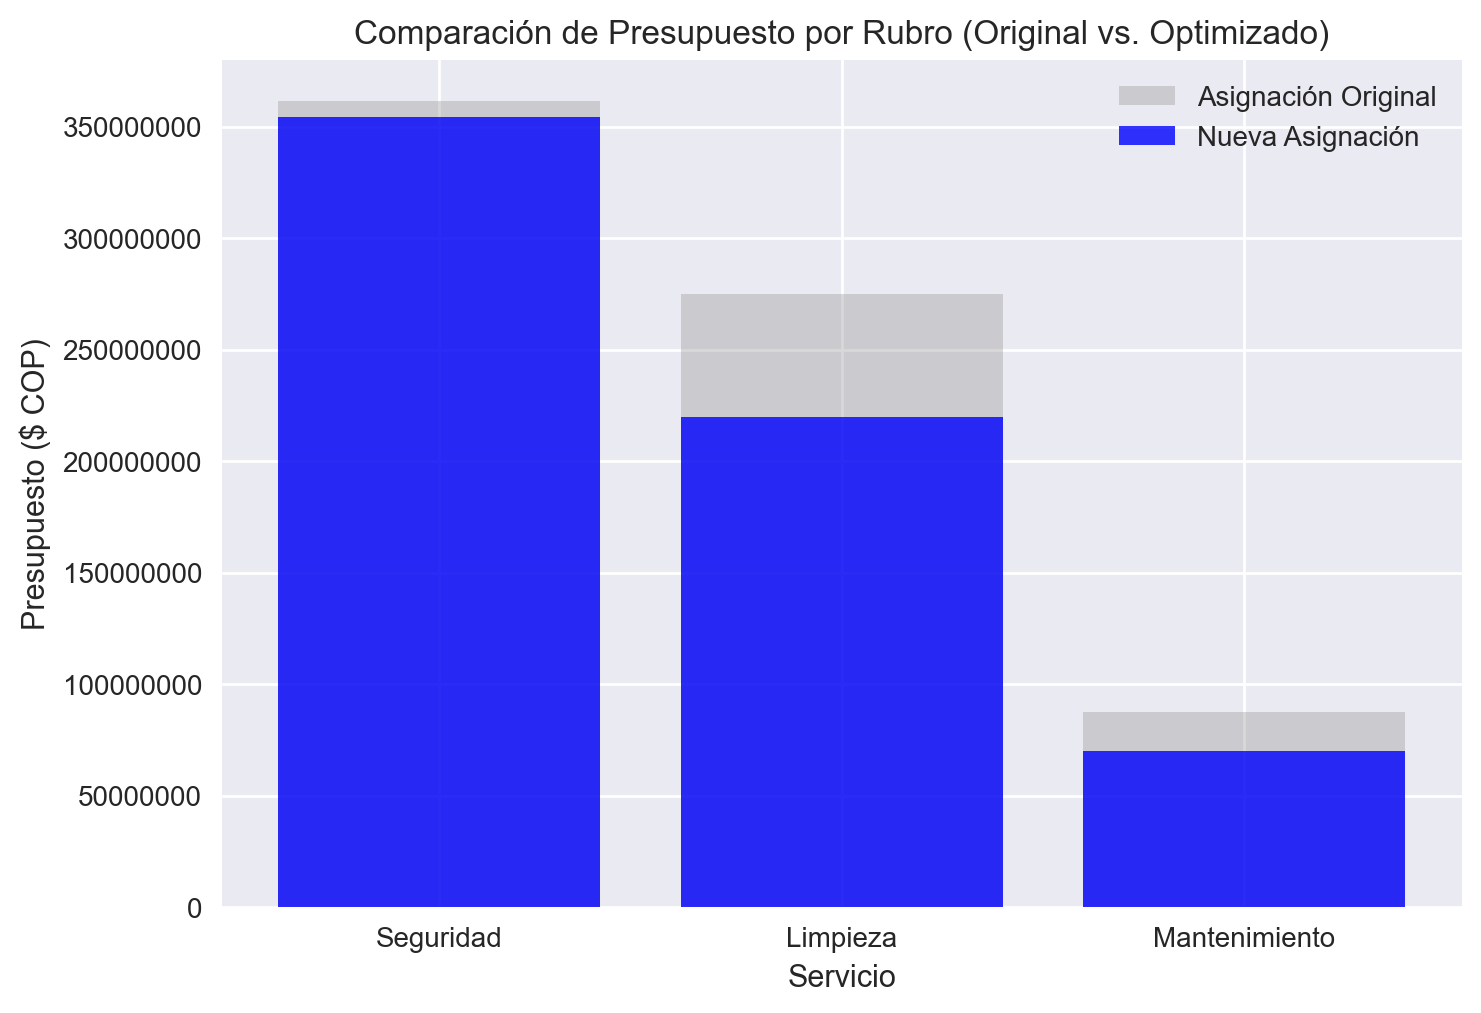

In [31]:
import matplotlib.pyplot as plt

# Tu configuración visual de siempre
%config InlineBackend.figure_format='retina'
plt.style.use("seaborn-v0_8")

# 1. Nombres cortos para el eje X
nombres_cortos = ['Seguridad', 'Limpieza', 'Mantenimiento']

# 2. Listas para guardar los valores
originales = []
optimizados = []

# Llenamos las listas de forma automática (igual que en tu print)
for i in I:
    valor_original = df_filtrado[df_filtrado['RUBRO'] == i]['VALOR'].iloc[0]
    valor_nuevo = x[i].varValue
    
    originales.append(valor_original)
    optimizados.append(valor_nuevo)

# 3. Creamos el gráfico superpuesto
# La barra original va al fondo (clarita como tu "Capacidad")
plt.bar(nombres_cortos, originales, alpha=0.3, label="Asignación Original", color="gray")

# La barra nueva va al frente (oscura como tu "Demanda atendida")
plt.bar(nombres_cortos, optimizados, alpha=0.8, label="Nueva Asignación", color="blue")

# 4. Decoración para que se entienda perfecto
plt.legend()
plt.xlabel("Servicio")
plt.ylabel("Presupuesto ($ COP)")
plt.title("Comparación de Presupuesto por Rubro (Original vs. Optimizado)")

# Truco para mostrar los millones completos y no con la "e"
plt.ticklabel_format(style='plain', axis='y')

plt.show()

**Explicación**

>El modelo encontro un resultado optimo, haciendo que la cantidad minima absoluta de pesos que el DADEP puede gastar cumpliendo las reglas exigidas es de $644.444.440 millones de pesos.

>El modelo tuvo en cuenta el dinero minimo del 80% que el parametro b asigno para limpieza siendo de $220.000.000 de pesos frente al original de $275.000.000 millones de pesos.

>Para el mantenimiento el modelo asigno la cifra de $70.000.000 millones de pesos frente al original de $87.500.000 millones de pesos.

>Para seguridad debido al parametro q, hace que esa area tuviera el 55% de porcentaje de inversion del nuevo gasto total de $644.444.440 millones de pesos, al multiplicarlo por este 0.55 hace que corresponda al valor de $354.444.440 millones de pesos.

In [ ]:
# 1. Calculamos los totales
total_original = df_filtrado['VALOR'].sum()
total_optimizado = lp.value(problema.objective)

# 2. Imprimimos los números directos
print("Original:", total_original)
print("Optimizado:", total_optimizado)
print("Ahorro:", total_original - total_optimizado)

Original: 724100000.0
Optimizado: 644444440.0
Ahorro: 79655560.0


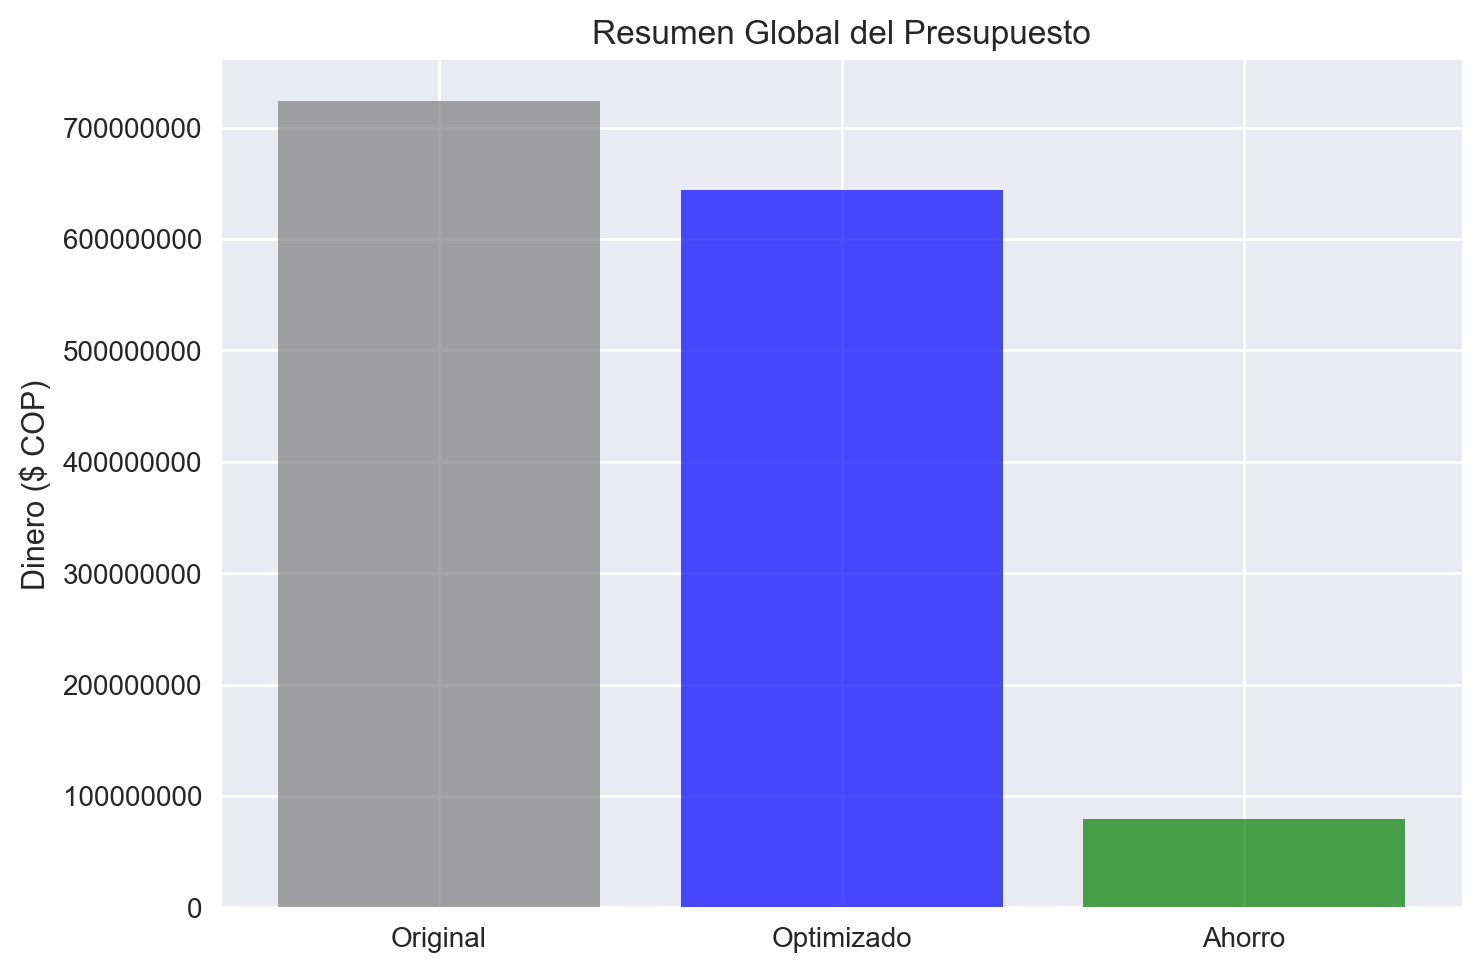

In [30]:
import matplotlib.pyplot as plt

# Tu configuración visual
%config InlineBackend.figure_format='retina'
plt.style.use("seaborn-v0_8")

# 1. Los 3 nombres y los 3 valores que ya calculaste
etiquetas = ['Original', 'Optimizado', 'Ahorro']
valores = [total_original, total_optimizado, total_original - total_optimizado]

# 2. Creamos un gráfico de barras simple (con colores diferentes para cada uno)
plt.bar(etiquetas, valores, color=['gray', 'blue', 'green'], alpha=0.7)

# 3. Decoración básica
plt.ylabel("Dinero ($ COP)")
plt.title("Resumen Global del Presupuesto")

# Truco para que no salgan los millones con "e" (notación científica)
plt.ticklabel_format(style='plain', axis='y')

plt.show()

**Explicación**

>La cantidad de dinero total que el DADEP estaba gastando originalmente en esos 3 servicios fue de $724.100.000 millones de pesos. 

>El nuevo presupuesto tras la optimización fue de $644.444.440 millones de pesos operando las 3 áreas con un mínimo de 80% y garantizando que el presupuesto de la seguridad fuera de mínimo 55%

> Con este resultado podemos concluir que el DADEP bajo estas condiciones podría ahorrar un total de $79.665.560 millones de pesos aplicándose por ejemplo si se vieran las necesidades de recortes presupuestales por áreas